<a href="https://colab.research.google.com/github/yuviiios/Generative-AI-Based-Cloud-Removal-and-Reconstruction-for-LISS-IV-Satellite-Imagery/blob/main/LISS4_CloudRemoval_Colab_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛰️ LISS-IV Cloud Removal — Colab Demo
**40 min end-to-end demo on free GPU**

In [1]:
!pip -q install torch torchvision rasterio scikit-image albumentations pyyaml
import torch
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

GPU: Tesla T4


In [5]:
import os
os.chdir('/content')
!git clone https://github.com/yuviiios/Generative-AI-Based-Cloud-Removal-and-Reconstruction-for-LISS-IV-Satellite-Imagery.git 2>/dev/null || echo exists
os.chdir('/content/Generative-AI-Based-Cloud-Removal-and-Reconstruction-for-LISS-IV-Satellite-Imagery')

import sys
sys.path.insert(0, os.getcwd())

print("Project directory:", os.getcwd())

exists
Project directory: /content/Generative-AI-Based-Cloud-Removal-and-Reconstruction-for-LISS-IV-Satellite-Imagery


In [3]:
import os

print("Current directory:", os.getcwd())
print("\n/content contents:")
print(os.listdir("/content"))

Current directory: /content

/content contents:
['.config', 'Generative-AI-Based-Cloud-Removal-and-Reconstruction-for-LISS-IV-Satellite-Imagery', 'sample_data']


In [4]:
!find /content -maxdepth 3 -type f -name "LISS4_CloudRemoval_Colab_Demo.ipynb"

/content/Generative-AI-Based-Cloud-Removal-and-Reconstruction-for-LISS-IV-Satellite-Imagery/LISS4_CloudRemoval_Colab_Demo.ipynb


In [6]:
import subprocess, glob
print('Downloading SEN12MS-CR...')
subprocess.run(['wget', '-q', 'https://mediatum.ub.tum.de/download/1700268', '-O', 'sen12mscr.zip'], timeout=600)
subprocess.run(['unzip', '-q', 'sen12mscr.zip'])
s2_files = sorted(glob.glob('SEN12MSCR/ROIs*_s2/*.tif'))
print(f'Found {len(s2_files)} scenes')

Found 0 scenes


In [ ]:
import rasterio, numpy as np
def extract_liss4(tif):
    with rasterio.open(tif) as src:
        g = np.clip(src.read(3).astype(np.float32) / 10000, 0, 1)
        r = np.clip(src.read(4).astype(np.float32) / 10000, 0, 1)
        n = np.clip(src.read(8).astype(np.float32) / 10000, 0, 1)
    return np.stack([g, r, n], axis=-1)
test = extract_liss4(s2_files[0])
print(f'Shape: {test.shape}')

In [14]:
from datasets import load_dataset
import numpy as np
import torch

print("⏳ Loading SEN12MS-CR...")

ds = load_dataset(
    "Hermanni/sen12mscr",
    split="train",
    streaming=True
)

sample = next(iter(ds))

cloudy = np.frombuffer(
    sample["cloudy"],
    dtype=np.int16
).reshape(sample["opt_shape"])

target = np.frombuffer(
    sample["target"],
    dtype=np.int16
).reshape(sample["opt_shape"])

print("Cloudy shape:", cloudy.shape)
print("Target shape:", target.shape)
print("✅ SEN12MS-CR loaded successfully")

⏳ Loading SEN12MS-CR...


README.md:   0%|          | 0.00/9.24k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/155 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/155 [00:00<?, ?it/s]

Cloudy shape: (256, 256, 13)
Target shape: (256, 256, 13)
✅ SEN12MS-CR loaded successfully


In [16]:
import numpy as np
from tqdm import tqdm

print("Preparing SEN12MS-CR samples...")

# Sentinel-2 band indices in SEN12MS-CR
# B4 = Red, B3 = Green, B8 = NIR
# Dataset order follows Sentinel-2 bands:
# B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B10, B11, B12

GREEN = 2
RED   = 3
NIR   = 7

def get_3band_sample(sample):
    cloudy = np.frombuffer(
        sample["cloudy"],
        dtype=np.int16
    ).reshape(sample["opt_shape"])

    target = np.frombuffer(
        sample["target"],
        dtype=np.int16
    ).reshape(sample["opt_shape"])

    # Extract Green, Red, NIR
    cloudy_3 = cloudy[:, :, [GREEN, RED, NIR]]
    target_3 = target[:, :, [GREEN, RED, NIR]]

    # Convert to float32 and normalize
    cloudy_3 = cloudy_3.astype(np.float32)
    target_3 = target_3.astype(np.float32)

    # SEN12MS values are scaled reflectance values
    cloudy_3 /= 10000.0
    target_3 /= 10000.0

    cloudy_3 = np.clip(cloudy_3, 0, 1)
    target_3 = np.clip(target_3, 0, 1)

    return cloudy_3, target_3


# Collect a manageable demo subset
cloudy_samples = []
target_samples = []

for i, sample in enumerate(ds):
    cloudy_img, target_img = get_3band_sample(sample)

    cloudy_samples.append(cloudy_img)
    target_samples.append(target_img)

    if i >= 99:
        break

cloudy_samples = np.stack(cloudy_samples)
target_samples = np.stack(target_samples)

print("Cloudy dataset:", cloudy_samples.shape)
print("Target dataset:", target_samples.shape)
print("Value range:", cloudy_samples.min(), "to", cloudy_samples.max())
print("✅ 3-band dataset prepared")

Preparing SEN12MS-CR samples...
Cloudy dataset: (100, 256, 256, 3)
Target dataset: (100, 256, 256, 3)
Value range: 0.0234 to 1.0
✅ 3-band dataset prepared


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class SEN12MSDataset(Dataset):
    def __init__(self, cloudy, target):
        self.cloudy = cloudy
        self.target = target

    def __len__(self):
        return len(self.cloudy)

    def __getitem__(self, idx):
        cloudy = torch.from_numpy(
            self.cloudy[idx].transpose(2, 0, 1)
        ).float()

        target = torch.from_numpy(
            self.target[idx].transpose(2, 0, 1)
        ).float()

        return cloudy, target


dataset = SEN12MSDataset(
    cloudy_samples,
    target_samples
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 80
Validation samples: 20


In [18]:
cloudy_batch, target_batch = next(iter(train_loader))

print("Cloudy batch:", cloudy_batch.shape)
print("Target batch:", target_batch.shape)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Cloudy batch: torch.Size([4, 3, 256, 256])
Target batch: torch.Size([4, 3, 256, 256])
Device: cuda


In [19]:
import torch
from src.model.unet import UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    in_channels=3,
    out_channels=3
).to(device)

print("Model:", model.__class__.__name__)
print("Device:", device)

# Test one batch
cloudy_batch, target_batch = next(iter(train_loader))

cloudy_batch = cloudy_batch.to(device)
target_batch = target_batch.to(device)

with torch.no_grad():
    output = model(cloudy_batch)

print("Input :", cloudy_batch.shape)
print("Output:", output.shape)
print("Target:", target_batch.shape)

Model: UNet
Device: cuda
Input : torch.Size([4, 3, 256, 256])
Output: torch.Size([4, 3, 256, 256])
Target: torch.Size([4, 3, 256, 256])


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.L1Loss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

for epoch in range(2):
    model.train()
    train_loss = 0.0

    for cloudy, target in train_loader:
        cloudy = cloudy.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad()

        output = model(cloudy)
        loss = criterion(output, target)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for cloudy, target in val_loader:
            cloudy = cloudy.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            output = model(cloudy)
            loss = criterion(output, target)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(
        f"Epoch {epoch + 1}/2 | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch 1/2 | Train Loss: 0.289382 | Val Loss: 0.198153
Epoch 2/2 | Train Loss: 0.130891 | Val Loss: 0.057044


In [21]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

model.eval()

psnr_values = []
ssim_values = []
mae_values = []

with torch.no_grad():
    for cloudy, target in val_loader:
        cloudy = cloudy.to(device)
        target = target.to(device)

        output = model(cloudy)

        # Keep predictions in valid reflectance range
        output = torch.clamp(output, 0, 1)

        for i in range(output.shape[0]):
            pred = output[i].cpu().numpy().transpose(1, 2, 0)
            true = target[i].cpu().numpy().transpose(1, 2, 0)

            mae = np.mean(np.abs(pred - true))

            psnr = peak_signal_noise_ratio(
                true,
                pred,
                data_range=1.0
            )

            ssim = structural_similarity(
                true,
                pred,
                channel_axis=2,
                data_range=1.0
            )

            mae_values.append(mae)
            psnr_values.append(psnr)
            ssim_values.append(ssim)

print(f"PSNR: {np.mean(psnr_values):.2f} dB")
print(f"SSIM: {np.mean(ssim_values):.4f}")
print(f"MAE : {np.mean(mae_values):.6f}")

PSNR: 23.41 dB
SSIM: 0.3771
MAE : 0.053620


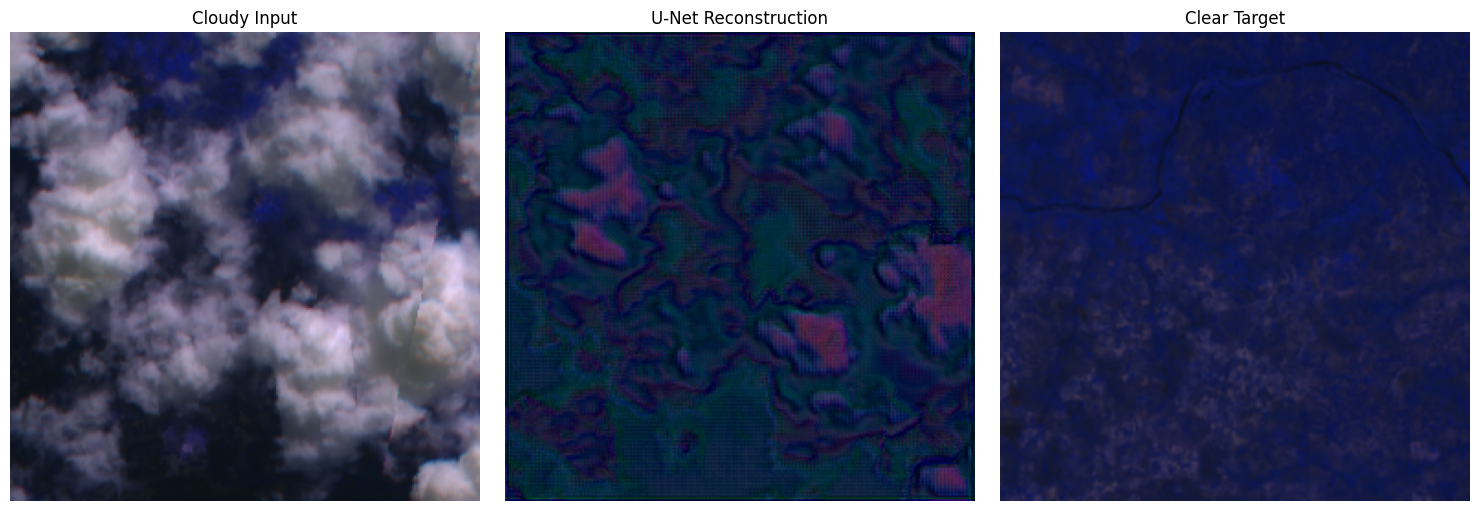

In [22]:
import matplotlib.pyplot as plt

model.eval()

cloudy, target = next(iter(val_loader))

with torch.no_grad():
    prediction = model(cloudy.to(device))

prediction = torch.clamp(prediction, 0, 1)

idx = 0

cloudy_img = cloudy[idx].numpy().transpose(1, 2, 0)
target_img = target[idx].numpy().transpose(1, 2, 0)
pred_img = prediction[idx].cpu().numpy().transpose(1, 2, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(
    np.clip(
        cloudy_img[:, :, [1, 0, 2]],
        0, 1
    )
)
axes[0].set_title("Cloudy Input")
axes[0].axis("off")

axes[1].imshow(
    np.clip(
        pred_img[:, :, [1, 0, 2]],
        0, 1
    )
)
axes[1].set_title("U-Net Reconstruction")
axes[1].axis("off")

axes[2].imshow(
    np.clip(
        target_img[:, :, [1, 0, 2]],
        0, 1
    )
)
axes[2].set_title("Clear Target")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Continue training the existing model
criterion = nn.L1Loss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = "/content/best_unet.pth"

for epoch in range(20):

    # -------------------------
    # Training
    # -------------------------
    model.train()
    running_train_loss = 0.0

    for cloudy, target in train_loader:

        cloudy = cloudy.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad()

        output = model(cloudy)

        # Keep output in reflectance range
        output = torch.clamp(output, 0, 1)

        loss = criterion(output, target)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for cloudy, target in val_loader:

            cloudy = cloudy.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            output = model(cloudy)
            output = torch.clamp(output, 0, 1)

            loss = criterion(output, target)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch+1:02d}/20 | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"LR: {scheduler.get_last_lr()[0]:.2e}"
    )

print("\n✅ Training complete")
print("Best model:", best_model_path)
print("Best validation loss:", best_val_loss)

Epoch 01/20 | Train Loss: 0.048903 | Val Loss: 0.035981 | LR: 9.94e-05
Epoch 02/20 | Train Loss: 0.035786 | Val Loss: 0.030078 | LR: 9.76e-05
Epoch 03/20 | Train Loss: 0.031440 | Val Loss: 0.026210 | LR: 9.46e-05
Epoch 04/20 | Train Loss: 0.029252 | Val Loss: 0.024784 | LR: 9.05e-05
Epoch 05/20 | Train Loss: 0.028064 | Val Loss: 0.024845 | LR: 8.54e-05
Epoch 06/20 | Train Loss: 0.026870 | Val Loss: 0.023703 | LR: 7.94e-05
Epoch 07/20 | Train Loss: 0.026346 | Val Loss: 0.023627 | LR: 7.27e-05
Epoch 08/20 | Train Loss: 0.026316 | Val Loss: 0.023388 | LR: 6.55e-05
Epoch 09/20 | Train Loss: 0.025812 | Val Loss: 0.023288 | LR: 5.78e-05
Epoch 10/20 | Train Loss: 0.025860 | Val Loss: 0.023548 | LR: 5.00e-05
Epoch 11/20 | Train Loss: 0.025404 | Val Loss: 0.023207 | LR: 4.22e-05
Epoch 12/20 | Train Loss: 0.025338 | Val Loss: 0.022732 | LR: 3.45e-05
Epoch 13/20 | Train Loss: 0.025055 | Val Loss: 0.022806 | LR: 2.73e-05
Epoch 14/20 | Train Loss: 0.024881 | Val Loss: 0.022705 | LR: 2.06e-05
Epoch 

In [24]:
model.load_state_dict(
    torch.load(
        "/content/best_unet.pth",
        map_location=device
    )
)

model.eval()

print("✅ Best model loaded")

✅ Best model loaded


In [25]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

model.eval()

psnr_values = []
ssim_values = []
mae_values = []

with torch.no_grad():
    for cloudy, target in val_loader:
        cloudy = cloudy.to(device)
        target = target.to(device)

        output = model(cloudy)
        output = torch.clamp(output, 0, 1)

        for i in range(output.shape[0]):
            pred = output[i].cpu().numpy().transpose(1, 2, 0)
            true = target[i].cpu().numpy().transpose(1, 2, 0)

            mae_values.append(np.mean(np.abs(pred - true)))

            psnr_values.append(
                peak_signal_noise_ratio(
                    true, pred, data_range=1.0
                )
            )

            ssim_values.append(
                structural_similarity(
                    true,
                    pred,
                    channel_axis=2,
                    data_range=1.0
                )
            )

print(f"PSNR: {np.mean(psnr_values):.2f} dB")
print(f"SSIM: {np.mean(ssim_values):.4f}")
print(f"MAE : {np.mean(mae_values):.6f}")

PSNR: 30.35 dB
SSIM: 0.7421
MAE : 0.022479


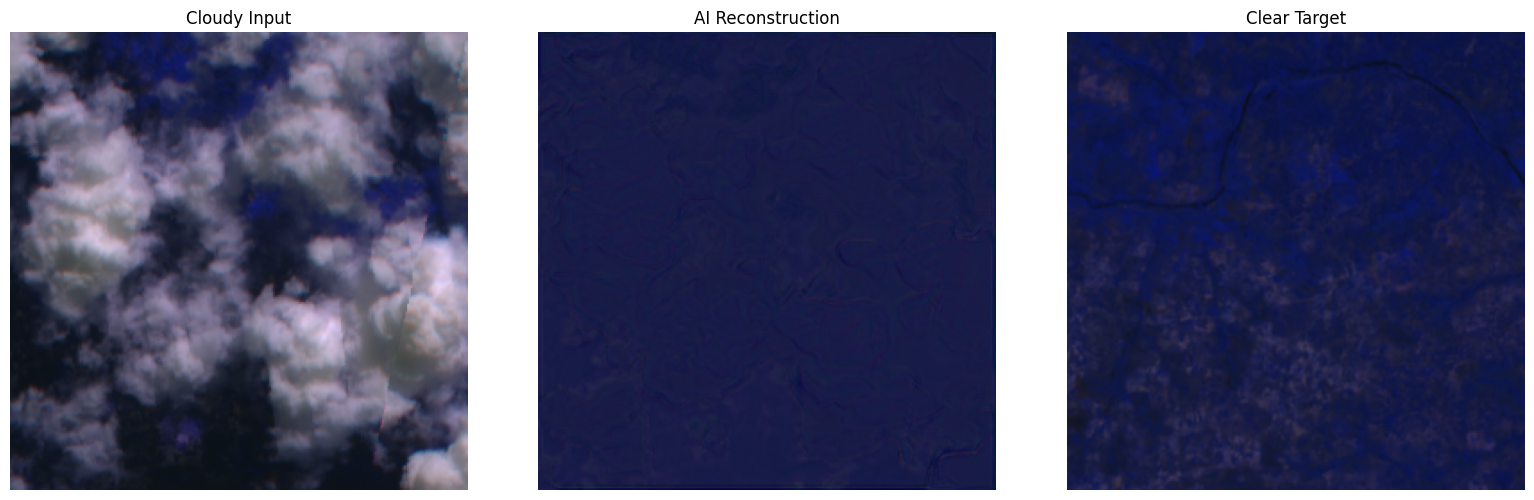

In [26]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

cloudy, target = next(iter(val_loader))

with torch.no_grad():
    prediction = model(cloudy.to(device))

prediction = torch.clamp(prediction, 0, 1)

idx = 0

cloudy_img = cloudy[idx].numpy().transpose(1, 2, 0)
pred_img = prediction[idx].cpu().numpy().transpose(1, 2, 0)
target_img = target[idx].numpy().transpose(1, 2, 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(
    np.clip(cloudy_img[:, :, [1, 0, 2]], 0, 1)
)
axes[0].set_title("Cloudy Input")

axes[1].imshow(
    np.clip(pred_img[:, :, [1, 0, 2]], 0, 1)
)
axes[1].set_title("AI Reconstruction")

axes[2].imshow(
    np.clip(target_img[:, :, [1, 0, 2]], 0, 1)
)
axes[2].set_title("Clear Target")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
import os
import torch

os.makedirs("/content/liss4_demo_model", exist_ok=True)

model_path = "/content/liss4_demo_model/best_unet.pth"

torch.save(model.state_dict(), model_path)

print("✅ Model saved:")
print(model_path)
print(f"Size: {os.path.getsize(model_path) / 1024**2:.2f} MB")

✅ Model saved:
/content/liss4_demo_model/best_unet.pth
Size: 29.68 MB


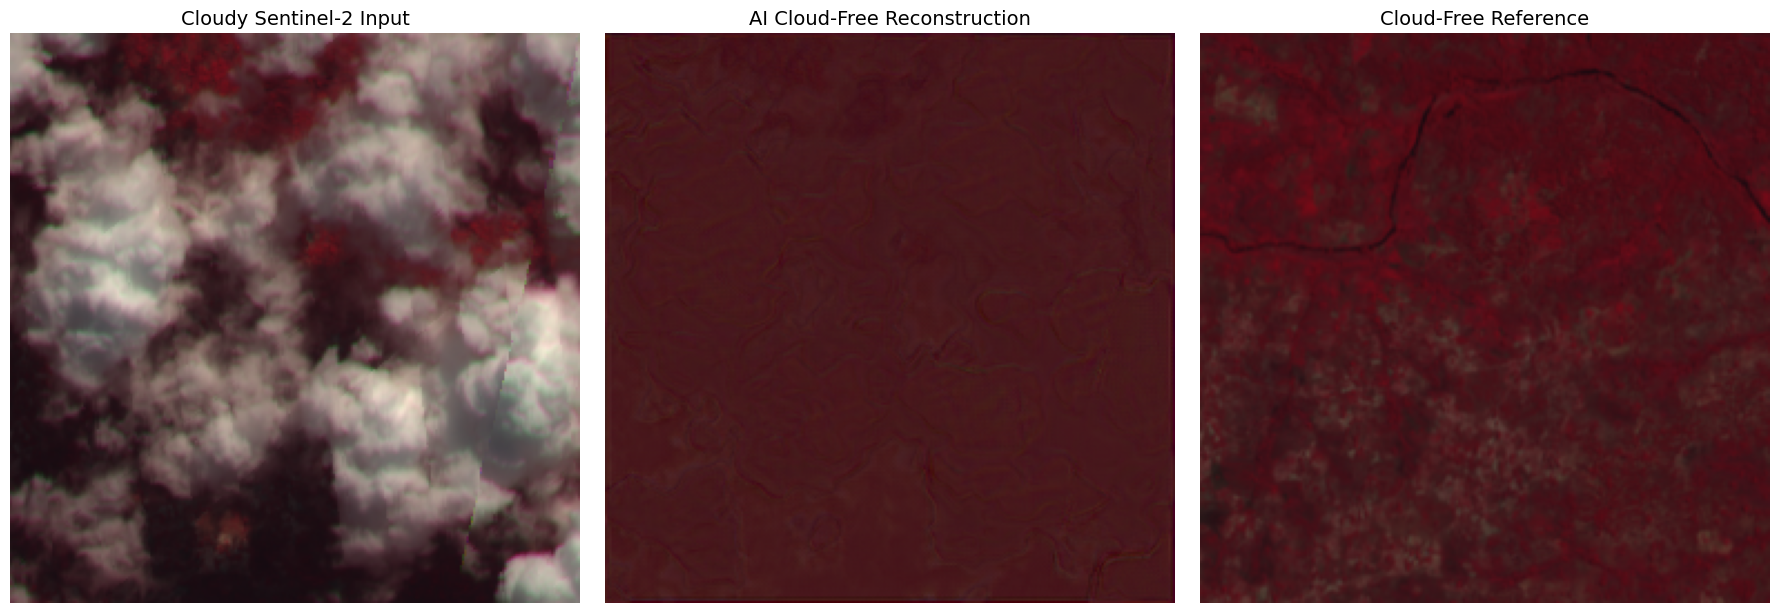

✅ Visualization saved


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

cloudy, target = next(iter(val_loader))

with torch.no_grad():
    prediction = model(cloudy.to(device))

prediction = torch.clamp(prediction, 0, 1)

idx = 0

cloudy_img = cloudy[idx].numpy().transpose(1, 2, 0)
pred_img = prediction[idx].cpu().numpy().transpose(1, 2, 0)
target_img = target[idx].numpy().transpose(1, 2, 0)

# False-color composite: NIR, Red, Green
cloudy_display = cloudy_img[:, :, [2, 1, 0]]
pred_display = pred_img[:, :, [2, 1, 0]]
target_display = target_img[:, :, [2, 1, 0]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(np.clip(cloudy_display, 0, 1))
axes[0].set_title("Cloudy Sentinel-2 Input", fontsize=14)

axes[1].imshow(np.clip(pred_display, 0, 1))
axes[1].set_title("AI Cloud-Free Reconstruction", fontsize=14)

axes[2].imshow(np.clip(target_display, 0, 1))
axes[2].set_title("Cloud-Free Reference", fontsize=14)

for ax in axes:
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/liss4_demo_model/reconstruction_result.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ Visualization saved")

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("🛰️ LISS-IV Cloud Removal — Inference Demo")
print("=" * 50)

# Upload an image
uploaded = files.upload()

filename = next(iter(uploaded))
print(f"✅ Uploaded: {filename}")

🛰️ LISS-IV Cloud Removal — Inference Demo


StopIteration: 

In [30]:
# Use one validation sample for inference

model.eval()

cloudy, target = next(iter(val_loader))

with torch.no_grad():
    prediction = model(
        cloudy.to(device)
    )

prediction = torch.clamp(prediction, 0, 1)

# Select first image
input_img = cloudy[0].cpu().numpy().transpose(1, 2, 0)
output_img = prediction[0].cpu().numpy().transpose(1, 2, 0)
target_img = target[0].cpu().numpy().transpose(1, 2, 0)

print("Input shape :", input_img.shape)
print("Output shape:", output_img.shape)
print("Target shape:", target_img.shape)

Input shape : (256, 256, 3)
Output shape: (256, 256, 3)
Target shape: (256, 256, 3)


/tmp/ipykernel_772/1518789227.py:22: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_772/1518789227.py:22: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


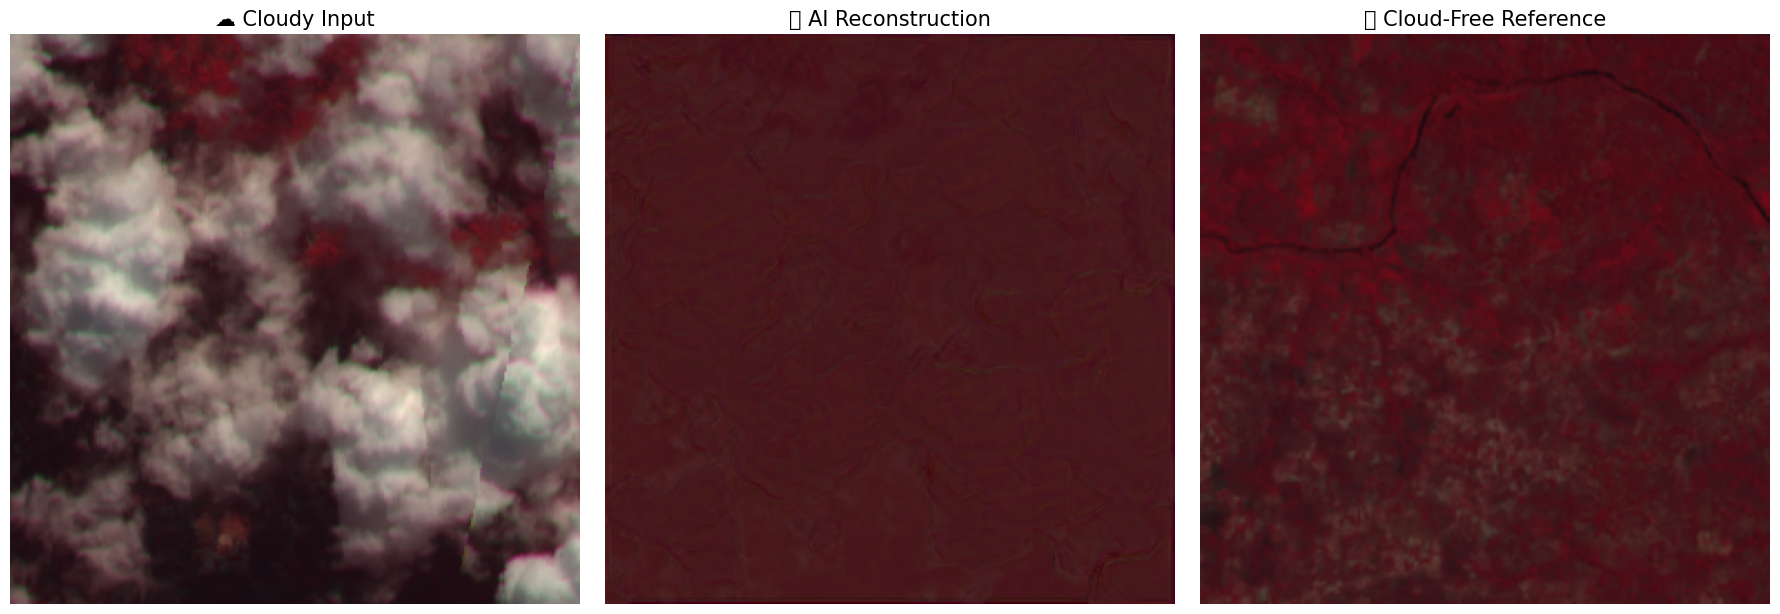

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# NIR / Red / Green false-color composite
axes[0].imshow(
    np.clip(input_img[:, :, [2, 1, 0]], 0, 1)
)
axes[0].set_title("☁️ Cloudy Input", fontsize=15)

axes[1].imshow(
    np.clip(output_img[:, :, [2, 1, 0]], 0, 1)
)
axes[1].set_title("🤖 AI Reconstruction", fontsize=15)

axes[2].imshow(
    np.clip(target_img[:, :, [2, 1, 0]], 0, 1)
)
axes[2].set_title("🌍 Cloud-Free Reference", fontsize=15)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()